In [1]:
import pandas as pd
import numpy as np

print("✔ Libraries loaded!")
base = r"C:\Users\Shyam\Documents\Python\VS code and SQL\Clinical Trial Disease Category Classification"

df = pd.read_csv(base + r"\clinical_trials_raw_patient2trial_conditions.csv", encoding="latin-1")

print("✔ files loaded!")

✔ Libraries loaded!
✔ files loaded!


In [2]:
df = pd.read_csv("clinical_trials_raw_patient2trial_conditions.csv")

In [3]:
df.head()

,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


In [4]:
print(df.shape)

(60337, 16)


In [5]:
print(df.columns)

Index(['source_condition_query', 'nct_id', 'title', 'official_title',
       'brief_summary', 'conditions', 'interventions', 'overall_status',
       'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age',
       'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60337 entries, 0 to 60336
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   source_condition_query  60337 non-null  str   
 1   nct_id                  60337 non-null  str   
 2   title                   60337 non-null  str   
 3   official_title          59551 non-null  str   
 4   brief_summary           60337 non-null  str   
 5   conditions              60336 non-null  str   
 6   interventions           54276 non-null  str   
 7   overall_status          60337 non-null  str   
 8   study_type              60337 non-null  str   
 9   phase                   23336 non-null  str   
 10  sex                     60304 non-null  str   
 11  minimum_age             57121 non-null  str   
 12  maximum_age             28400 non-null  str   
 13  healthy_volunteers      58857 non-null  object
 14  eligibility_criteria    60326 non-null  str   
 15  clinicaltrial

In [7]:
df.isnull().sum()

source_condition_query        0
nct_id                        0
title                         0
official_title              786
brief_summary                 0
conditions                    1
interventions              6061
overall_status                0
study_type                    0
phase                     37001
sex                          33
minimum_age                3216
maximum_age               31937
healthy_volunteers         1480
eligibility_criteria         11
clinicaltrials_url            0
dtype: int64

In [8]:
# unique() shows us every different disease category that exist
print(df['source_condition_query'].unique())

<ArrowStringArray>
[                        'breast cancer',
                              'covid-19',
 'chronic obstructive pulmonary disease',
                  'rheumatoid arthritis',
                       'type 2 diabetes',
                              'glaucoma',
                               'anxiety',
                    'sickle cell anemia']
Length: 8, dtype: str


In [9]:
# how many DIFFERENT categories there are
print(df['source_condition_query'].nunique())

8


In [10]:
# Let's also peek at 'conditions' to compare
print(df['conditions'].unique()[:20])

<ArrowStringArray>
[                                                                                                                                                                                                                                                                                              'Breast Cancer',
                                                                                                                                                                                                             'Breast Neoplasm Female | Mammography Screening | Decision Making | Information Seeking Behavior',
                                                                                                                                                                                                                                                                                'Malignant Neoplasm of Breast',
                                                  'Advanced Solid Tum

In [11]:
!pip install nltk


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import re     # 're' = "regular expressions" — a tool for finding/removing patterns in text
              # think of it like a super smart "find and replace"

import nltk   # nltk = Natural Language Toolkit, a toolbox made just for working with text
nltk.download('stopwords')   # downloads a list of "boring" words like "the", "is", "an"
nltk.download('wordnet')     # downloads a dictionary-like tool to shrink words to their root form
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))   # the list of boring words, as a fast lookup set
lemmatizer = WordNetLemmatizer()                # our word-shrinking tool

def clean_text(text):
    text = str(text).lower()                     # 1. make everything lowercase: "Cancer" -> "cancer"
    text = re.sub(r'[^a-z\s]', '', text)          # 2. remove anything that ISN'T a letter or space
                                                   #    (numbers, %, commas, etc. all get deleted)
    words = text.split()                          # 3. break the sentence into a list of separate words
    words = [w for w in words if w not in stop_words]   # 4. throw away boring words like "the", "and"
    words = [lemmatizer.lemmatize(w) for w in words]    # 5. shrink words to their root form
                                                         #    e.g. "patients" -> "patient", "studies" -> "study"
    return ' '.join(words)                        # 6. glue the words back into one clean sentence

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [13]:
# Apply this cleaning function to EVERY row in the brief_summary column
df['cleaned_summary'] = df['brief_summary'].apply(clean_text)

In [14]:
# Let's compare before and after
df[['brief_summary', 'cleaned_summary']].head()

,brief_summary,cleaned_summary
0,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
1,Many breast cancer patients experience psychol...,many breast cancer patient experience psycholo...
2,"Based on an American study by Scherer et al., ...",based american study scherer et al hypothesize...
3,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
4,Phase 1 dose escalation and expansion study of...,phase dose escalation expansion study clsp fir...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# TfidfVectorizer is a tool that reads all our cleaned sentences
# and turns each one into a row of numbers (a "vector").
# max_features=5000 means: "only keep the 5000 most useful words" —
# this keeps things fast and avoids drowning in rare, useless words.
tfidf = TfidfVectorizer(max_features=5000)

# fit_transform does two things at once:
#   1. "fit" = studies all the sentences to learn which words exist
#   2. "transform" = converts every sentence into its number-row
X = tfidf.fit_transform(df['cleaned_summary'])

# Our labels (the 8 disease names) are text right now: "breast cancer", "covid-19"...
# Machine learning models want numbers instead, so we convert each
# disease name into a number ID (e.g. "breast cancer" -> 0, "covid-19" -> 1, etc.)
le = LabelEncoder()
y = le.fit_transform(df['source_condition_query'])

# Let's peek at what the encoder did
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Now we split our data into a "practice set" (train) and a "quiz set" (test).
# The robot only studies from the train set — the test set is kept hidden
# so we can fairly check how well it actually learned, like a real exam.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# test_size=0.2 -> keep 20% of notes aside as the "hidden exam"
# random_state=42 -> makes the split repeatable (same split every time we run it)
# stratify=y -> makes sure each disease category is fairly represented in both sets

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

{'anxiety': np.int64(0), 'breast cancer': np.int64(1), 'chronic obstructive pulmonary disease': np.int64(2), 'covid-19': np.int64(3), 'glaucoma': np.int64(4), 'rheumatoid arthritis': np.int64(5), 'sickle cell anemia': np.int64(6), 'type 2 diabetes': np.int64(7)}
Training samples: 48269
Testing samples: 12068


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the "student robot". max_iter=1000 just gives it enough
# attempts to fully finish studying (like giving it enough time to
# read through its notes properly before we stop it).
model = LogisticRegression(max_iter=1000)

# .fit() is the actual "studying" step —
# the robot looks at X_train (the notes) and y_train (the correct answers)
# and learns the patterns that connect them.
model.fit(X_train, y_train)

# Now let's give the robot the "exam" — X_test —
# and see what answers it guesses, WITHOUT showing it y_test (the real answers).
y_pred = model.predict(X_test)

# accuracy_score compares the robot's guesses (y_pred) to the real answers (y_test)
# and tells us what % it got right.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# classification_report gives a detailed report card PER disease category:
# precision = "when it said X, how often was it actually X?"
# recall    = "out of all real X cases, how many did it catch?"
# f1-score  = a balanced mix of precision and recall
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.944729864103414
                                       precision    recall  f1-score   support

                              anxiety       0.90      0.97      0.93      1857
                        breast cancer       0.96      0.97      0.96      3260
chronic obstructive pulmonary disease       0.93      0.91      0.92      1236
                             covid-19       0.97      0.93      0.95      2031
                             glaucoma       0.98      0.92      0.95       435
                 rheumatoid arthritis       0.96      0.88      0.92       727
                   sickle cell anemia       0.98      0.82      0.90       228
                      type 2 diabetes       0.94      0.96      0.95      2294

                             accuracy                           0.94     12068
                            macro avg       0.95      0.92      0.93     12068
                         weighted avg       0.95      0.94      0.94     12068



In [17]:
from sklearn.tree import DecisionTreeClassifier

# Create the "student robot" that learns by asking yes/no questions about words
dt_model = DecisionTreeClassifier(random_state=42)

# .fit() = studying: robot looks at the practice notes + correct answers
dt_model.fit(X_train, y_train)

# .predict() = taking the hidden exam
y_pred_dt = dt_model.predict(X_test)

# Check how many it got right, and the detailed report card
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Decision Tree Accuracy: 0.9105071262843885
                                       precision    recall  f1-score   support

                              anxiety       0.87      0.89      0.88      1857
                        breast cancer       0.93      0.94      0.94      3260
chronic obstructive pulmonary disease       0.86      0.86      0.86      1236
                             covid-19       0.93      0.92      0.93      2031
                             glaucoma       0.92      0.91      0.91       435
                 rheumatoid arthritis       0.86      0.85      0.85       727
                   sickle cell anemia       0.94      0.83      0.88       228
                      type 2 diabetes       0.94      0.92      0.93      2294

                             accuracy                           0.91     12068
                            macro avg       0.91      0.89      0.90     12068
                         weighted avg       0.91      0.91      0.91     12068



In [18]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100 means: "grow 100 different trees and let them vote together"
# random_state=42 keeps results repeatable (same forest every time we run this)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)          # studying
y_pred_rf = rf_model.predict(X_test)    # taking the exam

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.9396751740139211
                                       precision    recall  f1-score   support

                              anxiety       0.88      0.96      0.92      1857
                        breast cancer       0.94      0.97      0.96      3260
chronic obstructive pulmonary disease       0.94      0.87      0.91      1236
                             covid-19       0.97      0.93      0.95      2031
                             glaucoma       0.96      0.94      0.95       435
                 rheumatoid arthritis       0.97      0.86      0.91       727
                   sickle cell anemia       1.00      0.82      0.90       228
                      type 2 diabetes       0.95      0.96      0.95      2294

                             accuracy                           0.94     12068
                            macro avg       0.95      0.91      0.93     12068
                         weighted avg       0.94      0.94      0.94     12068



In [19]:
import pickle   # pickle is a built-in Python library — no need to install it!
                 # it "pickles" (preserves) a Python object into a file, like preserving food in a jar 🫙

# Save the trained model into a file called 'model.pkl'
# 'wb' means "write, in binary mode" — models aren't plain text, so we save them as raw bytes
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the TF-IDF vectorizer the same way
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save the label encoder the same way
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("All three files saved successfully! ✅")

All three files saved successfully! ✅


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice-looking style for all our charts (like choosing a theme for your drawings)
sns.set_style("darkgrid")

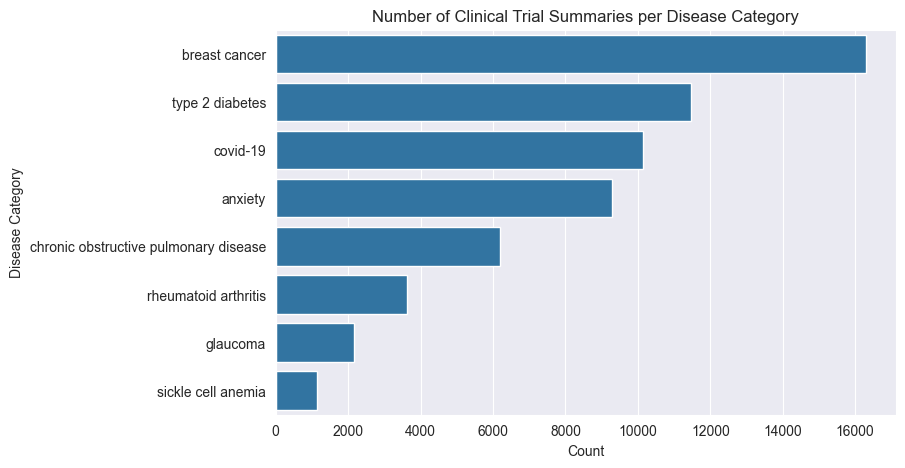

In [21]:
plt.figure(figsize=(8,5))     # figsize = how big the chart image should be (width, height in inches)

# countplot literally COUNTS how many rows belong to each disease category
# and draws a bar for each one
sns.countplot(data=df, y='source_condition_query', order=df['source_condition_query'].value_counts().index)

plt.title("Number of Clinical Trial Summaries per Disease Category")
plt.xlabel("Count")
plt.ylabel("Disease Category")
plt.show()

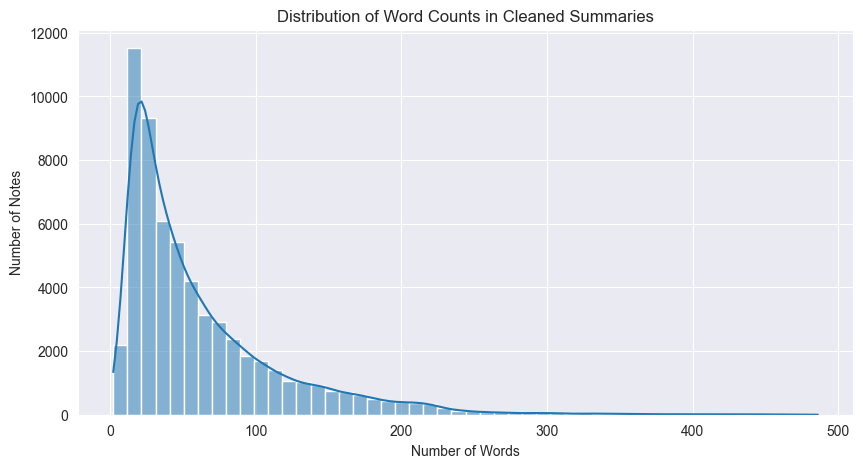

count    60337.000000
mean        61.950395
std         56.440009
min          2.000000
25%         23.000000
50%         42.000000
75%         81.000000
max        486.000000
Name: word_count, dtype: float64


In [22]:
# Count how many words are in each cleaned summary
df['word_count'] = df['cleaned_summary'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True)   # histogram = bars showing how many notes fall into each "length range"
                                                       # kde=True adds a smooth curve on top, like a trend line
plt.title("Distribution of Word Counts in Cleaned Summaries")
plt.xlabel("Number of Words")
plt.ylabel("Number of Notes")
plt.show()

print(df['word_count'].describe())   # gives min, max, average, etc.

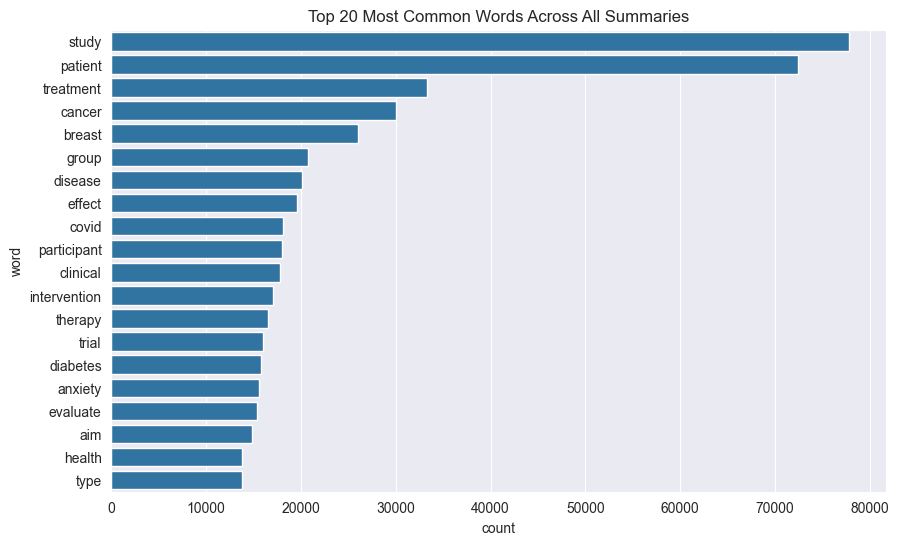

In [23]:
from collections import Counter

# Combine every single cleaned note into one giant list of words
all_words = ' '.join(df['cleaned_summary']).split()

# Counter counts how many times each word appears — like tally marks for every word
word_freq = Counter(all_words)

# Get the top 20 most common words
top_words = word_freq.most_common(20)
top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(10,6))
sns.barplot(data=top_words_df, x='count', y='word')
plt.title("Top 20 Most Common Words Across All Summaries")
plt.show()

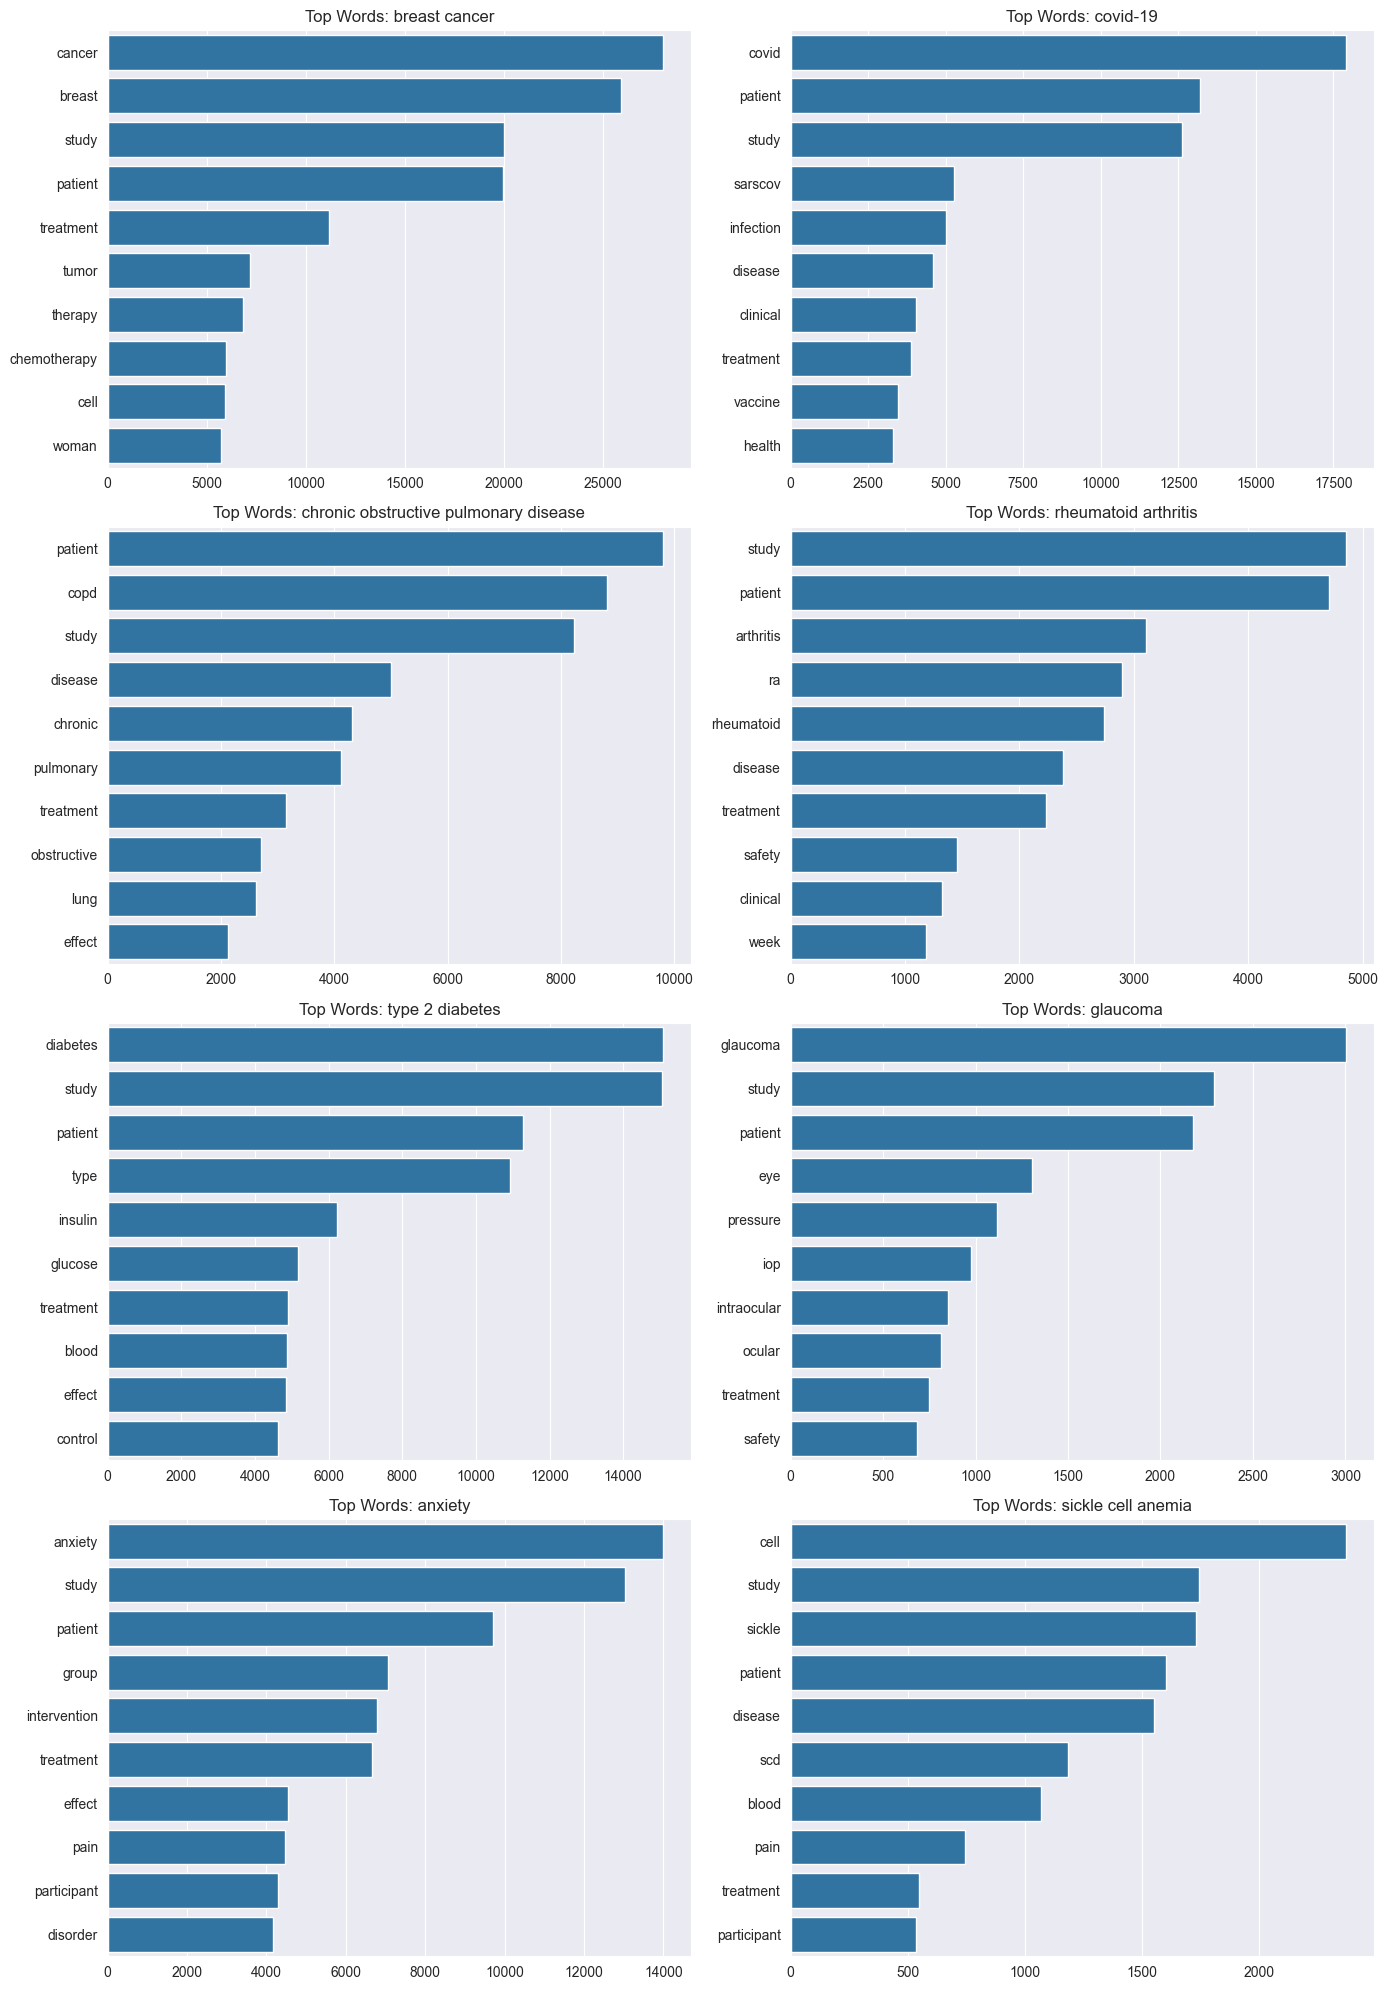

In [24]:
diseases = df['source_condition_query'].unique()

fig, axes = plt.subplots(4, 2, figsize=(14, 20))   # makes a grid of 8 small charts (4 rows, 2 columns)
axes = axes.flatten()                                # flattens the grid into a simple list, easier to loop through

for i, disease in enumerate(diseases):
    # Grab only the cleaned summaries belonging to THIS disease
    subset = df[df['source_condition_query'] == disease]['cleaned_summary']
    words = ' '.join(subset).split()
    common = Counter(words).most_common(10)          # top 10 words for just this disease
    words_list, counts_list = zip(*common)            # split the (word, count) pairs into two separate lists

    sns.barplot(x=list(counts_list), y=list(words_list), ax=axes[i])
    axes[i].set_title(f"Top Words: {disease}")

plt.tight_layout()   # automatically fixes spacing so charts don't overlap
plt.show()